# Regression Algorithms In Practice
## Unit 3, Day 3 - Interactive Walkthrough

**Instructor:** Abishek Ganesh

Welcome! In this notebook, we'll explore different regression algorithms and see how they work.

**Required Files:** Make sure you have these CSV files in the same folder as this notebook:
- `simple_housing.csv` (housing data with square footage, bedrooms, and price)
- `car_prices.csv` (car data with mileage and price)

**Instructions:** Run each cell in order (Shift + Enter) and observe the outputs!

**What we'll cover:**
1. Linear Regression Review (connecting to December)
2. Polynomial Regression (when straight lines aren't enough)
3. Overfitting vs Underfitting (the Goldilocks problem)
4. Decision Tree Regression (a completely different approach)
5. Regularization (Ridge, Lasso, ElasticNet)
6. Hyperparameter Tuning
7. Model Comparison

---
## Setup: Import Libraries

Run this cell first to load all the tools we'll need.

In [13]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score

# For nicer plots
plt.style.use('seaborn-v0_8-whitegrid')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


---
# Part 1: Linear Regression Review
## Reconnecting to December - You Already Know This!

Let's refresh what we learned in Unit 2 with the housing data.

> **Analogy:** Linear regression is like drawing the best trend line through a scatter plot - except the computer finds the mathematically optimal line instead of us eyeballing it.

### Load the Housing Data

In [14]:
# Load our familiar housing dataset from Unit 2
df_housing = pd.read_csv('simple_housing.csv')

print(f"Dataset shape: {df_housing.shape}")
print(f"Columns: {df_housing.columns.tolist()}")
print("\nFirst 10 rows:")
df_housing.head(10)

Dataset shape: (55, 3)
Columns: ['SquareFootage', 'Bedrooms', 'Price']

First 10 rows:


,SquareFootage,Bedrooms,Price
0,1200,2,189000
1,1350,2,198000
2,1500,3,232000
3,1425,2,205000
4,1600,3,258000
5,1750,3,251000
6,1550,3,242000
7,1800,4,295000
8,1650,3,238000
9,1900,4,305000


In [15]:
# Quick statistics
df_housing.describe()

,SquareFootage,Bedrooms,Price
count,55.000000,55.000000,55.000000
mean,1871.909091,3.581818,287000.000000
std,356.113916,0.994260,61927.974891
min,1200.000000,2.000000,178000.000000
25%,1587.500000,3.000000,236500.000000
50%,1850.000000,4.000000,285000.000000
75%,2162.500000,4.000000,340000.000000
max,2500.000000,5.000000,398000.000000


### 1A: Simple Linear Regression

Let's predict house **Price** using just **SquareFootage**.

In [17]:
# Define features (X) and target (y)
X_simple = df_housing[['SquareFootage']]  # Double brackets = 2D array
y = df_housing['Price']

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f"Features shape: {X_simple.shape}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Features shape: (55, 1)
Training samples: 44
Testing samples: 11


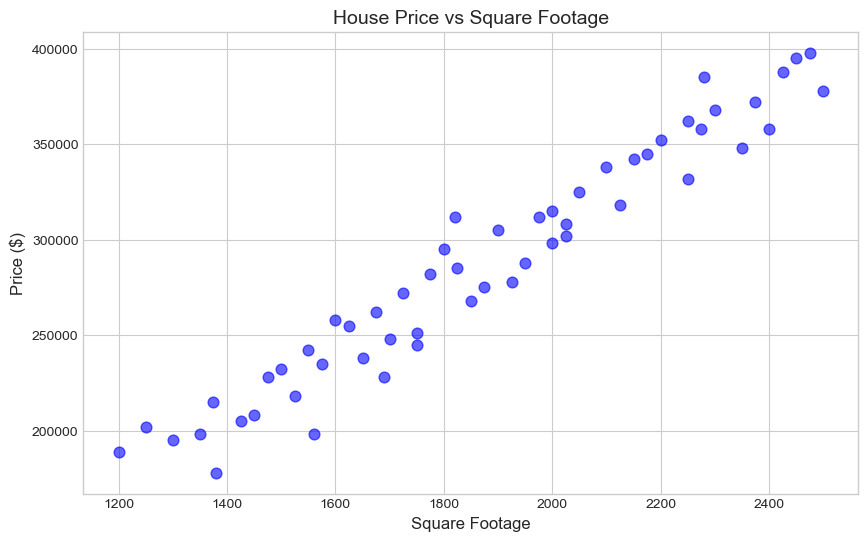

Does this look like a linear relationship? Let's find out!


In [18]:
# Visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(X_simple, y, color='blue', alpha=0.6, s=60)
plt.xlabel('Square Footage', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('House Price vs Square Footage', fontsize=14)
plt.show()

print("Does this look like a linear relationship? Let's find out!")

In [19]:
# Create and train the model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Model trained!")
print(f"\nWhat the model learned:")
print(f"  Slope (coefficient): {model_simple.coef_[0]:.2f}")
print(f"  Intercept: {model_simple.intercept_:.2f}")
print(f"\nInterpretation: For every 1 sq ft increase, price increases by ${model_simple.coef_[0]:.2f}")

Model trained!

What the model learned:
  Slope (coefficient): 167.34
  Intercept: -25845.81

Interpretation: For every 1 sq ft increase, price increases by $167.34


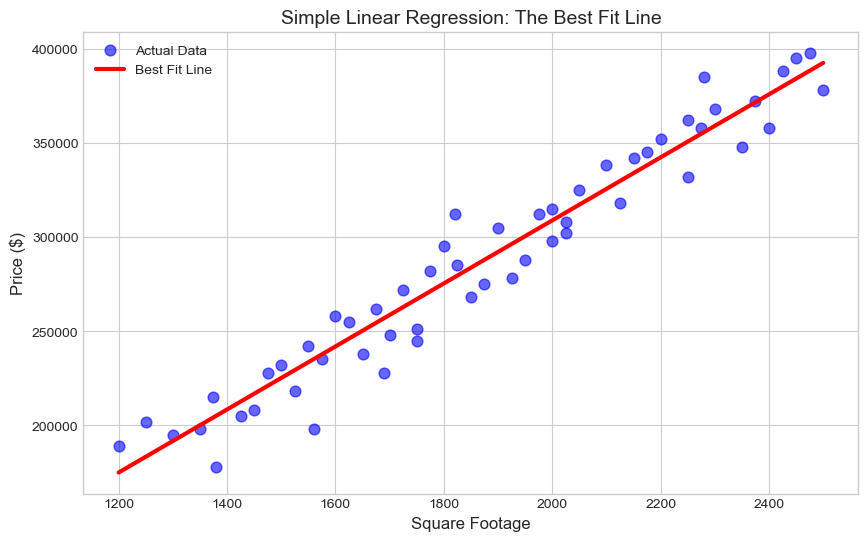

In [20]:
# Visualize the best-fit line
plt.figure(figsize=(10, 6))

# Scatter plot of all data
plt.scatter(df_housing['SquareFootage'], df_housing['Price'], 
            color='blue', alpha=0.6, s=60, label='Actual Data')

# Create the regression line
X_line = np.linspace(df_housing['SquareFootage'].min(), 
                     df_housing['SquareFootage'].max(), 100).reshape(-1, 1)
y_line = model_simple.predict(X_line)

# Plot the line
plt.plot(X_line, y_line, color='red', linewidth=3, label='Best Fit Line')

plt.xlabel('Square Footage', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Simple Linear Regression: The Best Fit Line', fontsize=14)
plt.legend()
plt.show()

In [21]:
# Evaluate the model
y_pred_simple = model_simple.predict(X_test)

r2_simple = r2_score(y_test, y_pred_simple)
rmse_simple = np.sqrt(mean_squared_error(y_test, y_pred_simple))

print("=" * 50)
print("SIMPLE LINEAR REGRESSION RESULTS")
print("=" * 50)
print(f"R² Score: {r2_simple:.4f}")
print(f"RMSE: ${rmse_simple:,.2f}")
print("=" * 50)
print("\nThis is our BASELINE to beat!")

SIMPLE LINEAR REGRESSION RESULTS
R² Score: 0.9211
RMSE: $15,647.35

This is our BASELINE to beat!


### 1B: Multiple Linear Regression

Can we do better by using **both** SquareFootage AND Bedrooms?

> **Consulting Story:** In health tech, I've used multiple regression to predict hospital length of stay. We started with just diagnosis codes, but adding patient age, comorbidities, and admission type dramatically improved predictions. Each feature added a piece of the puzzle - just like adding bedrooms to square footage gives us a fuller picture of house prices.

In [22]:
# Use both features
X_multi = df_housing[['SquareFootage', 'Bedrooms']]

# Split and train
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

print(f"Features shape: {X_multi.shape}")
print("Now we have 2 features instead of 1!")
print("\nMultiple regression model trained!")

Features shape: (55, 2)
Now we have 2 features instead of 1!

Multiple regression model trained!


In [23]:
# Interpret the coefficients
print("Coefficients (how much each feature affects price):")
print("-" * 50)
for feature, coef in zip(['SquareFootage', 'Bedrooms'], model_multi.coef_):
    print(f"  {feature}: ${coef:.2f}")
print(f"\nIntercept: ${model_multi.intercept_:.2f}")
print("-" * 50)
print("\nInterpretation:")
print(f"  - Each additional sq ft adds ${model_multi.coef_[0]:.2f} to price")
print(f"  - Each additional bedroom adds ${model_multi.coef_[1]:.2f} to price")
print("\n(Interesting - bedrooms have a NEGATIVE coefficient! Why might that be?)")

Coefficients (how much each feature affects price):
--------------------------------------------------
  SquareFootage: $176.12
  Bedrooms: $-3239.52

Intercept: $-30644.00
--------------------------------------------------

Interpretation:
  - Each additional sq ft adds $176.12 to price
  - Each additional bedroom adds $-3239.52 to price

(Interesting - bedrooms have a NEGATIVE coefficient! Why might that be?)


In [24]:
# Evaluate multiple regression
y_pred_multi = model_multi.predict(X_test_m)

r2_multi = r2_score(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test_m, y_pred_multi))

print("=" * 50)
print("MODEL COMPARISON: Simple vs Multiple")
print("=" * 50)
print(f"Simple Linear (sqft only):     R² = {r2_simple:.4f}, RMSE = ${rmse_simple:,.2f}")
print(f"Multiple Linear (sqft + beds): R² = {r2_multi:.4f}, RMSE = ${rmse_multi:,.2f}")
print("=" * 50)

if r2_multi > r2_simple:
    print(f"\nAdding bedrooms improved R² by {(r2_multi - r2_simple):.4f}!")
else:
    print("\nAdding bedrooms didn't help much - sqft is already very predictive.")

MODEL COMPARISON: Simple vs Multiple
Simple Linear (sqft only):     R² = 0.9211, RMSE = $15,647.35
Multiple Linear (sqft + beds): R² = 0.9244, RMSE = $15,319.59

Adding bedrooms improved R² by 0.0033!


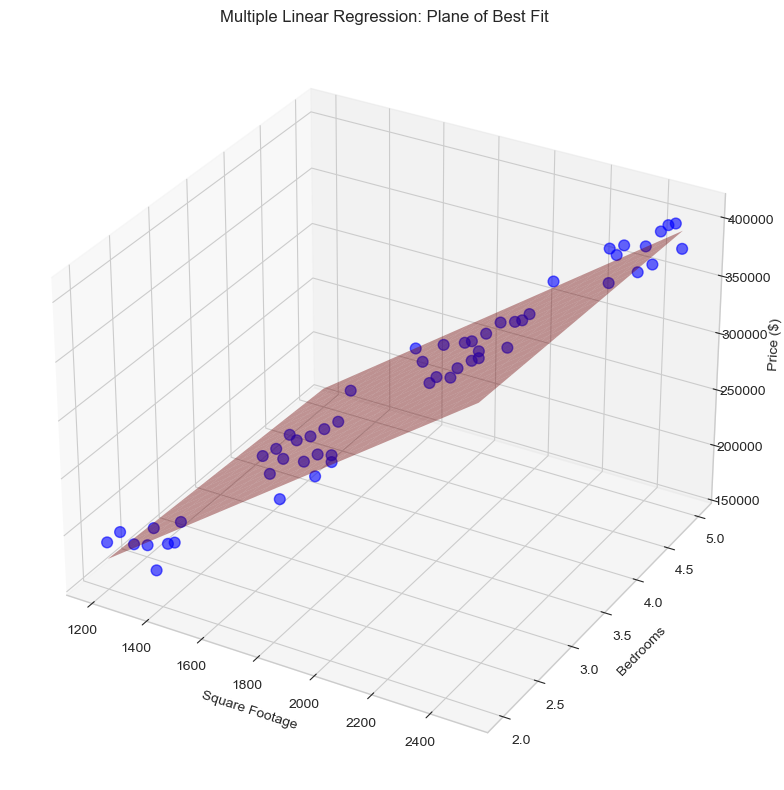

With 2 features, we fit a PLANE instead of a LINE!
Try rotating this plot by clicking and dragging!


In [25]:
# 3D Visualization - see the plane of best fit!
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot actual data points
ax.scatter(df_housing['SquareFootage'], df_housing['Bedrooms'], df_housing['Price'], 
           c='blue', s=60, alpha=0.6, label='Actual Data')

# Create mesh grid for the plane
sqft_range = np.linspace(df_housing['SquareFootage'].min(), df_housing['SquareFootage'].max(), 20)
bed_range = np.linspace(df_housing['Bedrooms'].min(), df_housing['Bedrooms'].max(), 20)
sqft_grid, bed_grid = np.meshgrid(sqft_range, bed_range)

# Predict prices for the grid
price_grid = model_multi.predict(
    np.column_stack([sqft_grid.ravel(), bed_grid.ravel()])
).reshape(sqft_grid.shape)

# Plot the plane
ax.plot_surface(sqft_grid, bed_grid, price_grid, alpha=0.4, color='red')

ax.set_xlabel('Square Footage')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price ($)')
ax.set_title('Multiple Linear Regression: Plane of Best Fit')

plt.tight_layout()
plt.show()

print("With 2 features, we fit a PLANE instead of a LINE!")
print("Try rotating this plot by clicking and dragging!")

---
# Part 2: Polynomial Regression
## When Straight Lines Aren't Enough

Not all relationships are linear. Let's look at a dataset where a straight line just won't cut it!

> **Analogy:** Think of polynomial regression like upgrading from a ruler to a flexible curve tool. Linear regression can only draw straight lines. Polynomial regression can bend and curve to follow the data's natural shape.
>
> - **Degree 1** = Straight line (regular linear regression)
> - **Degree 2** = One bend (like a U or arch)
> - **Degree 3** = Two bends (like an S)
> - And so on...

### Load the Car Prices Dataset

This dataset shows **car prices** based on **mileage**. Think about it:
- New cars (low mileage) are expensive
- Price drops quickly at first
- But a 100k-mile car isn't much cheaper than a 150k-mile car

This creates a **curved relationship**!

In [27]:
# Load car prices data
df_cars = pd.read_csv('car_prices.csv')

print(f"Dataset shape: {df_cars.shape}")
print("\nFirst 10 rows:")
df_cars.head(10)

Dataset shape: (80, 2)

First 10 rows:


,Mileage,Price
0,5801,31184
1,7985,30712
2,9986,27292
3,11558,26810
4,11735,25328
5,13422,24256
6,14432,26730
7,15736,26874
8,15810,24695
9,17831,25319


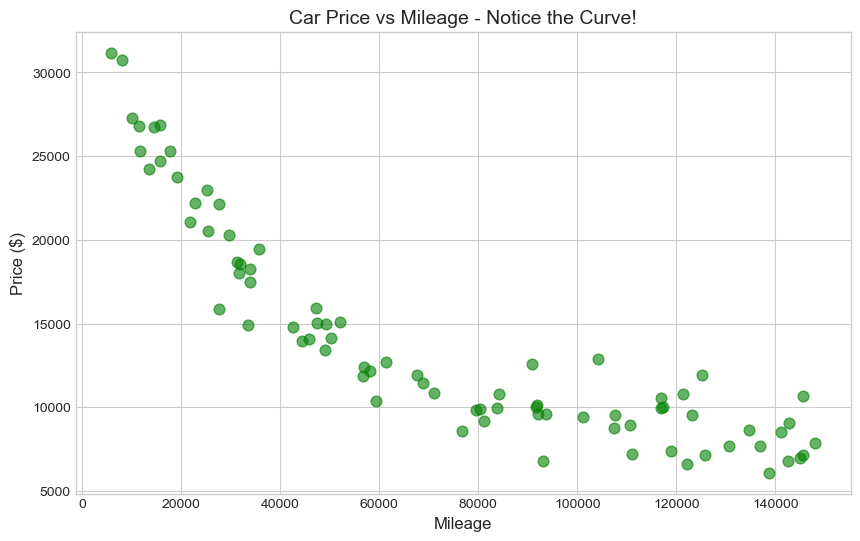

This is NOT a straight line relationship!
Prices drop fast at first, then level off.


In [28]:
# Visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df_cars['Mileage'], df_cars['Price'], color='green', alpha=0.6, s=60)
plt.xlabel('Mileage', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Car Price vs Mileage - Notice the Curve!', fontsize=14)
plt.show()

print("This is NOT a straight line relationship!")
print("Prices drop fast at first, then level off.")

### First, Let's Try Linear Regression

What happens when we force a straight line through this curved data?

In [29]:
# Prepare data
X_car = df_cars[['Mileage']]
y_car = df_cars['Price']

# Split
X_train_car, X_test_car, y_train_car, y_test_car = train_test_split(
    X_car, y_car, test_size=0.2, random_state=42
)

# IMPORTANT: Scale the data for polynomial regression
# This prevents numerical issues with large numbers raised to high powers
scaler_car = StandardScaler()
X_train_car_scaled = scaler_car.fit_transform(X_train_car)
X_test_car_scaled = scaler_car.transform(X_test_car)

# Train linear model on scaled data
model_car_linear = LinearRegression()
model_car_linear.fit(X_train_car_scaled, y_train_car)

# Evaluate
y_pred_car_linear = model_car_linear.predict(X_test_car_scaled)
r2_car_linear = r2_score(y_test_car, y_pred_car_linear)
rmse_car_linear = np.sqrt(mean_squared_error(y_test_car, y_pred_car_linear))

print(f"Linear Regression on Car Data:")
print(f"R² Score: {r2_car_linear:.4f}")
print(f"RMSE: ${rmse_car_linear:,.2f}")

Linear Regression on Car Data:
R² Score: 0.7330
RMSE: $3,366.99


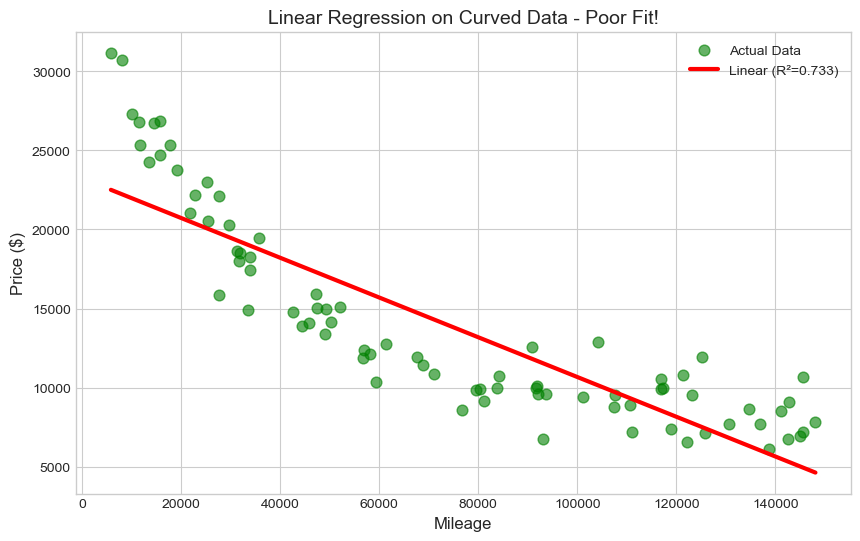

See how the line misses the curve?
It overestimates low-mileage cars and underestimates mid-mileage cars.


In [30]:
# Visualize the poor fit
plt.figure(figsize=(10, 6))

plt.scatter(df_cars['Mileage'], df_cars['Price'], color='green', alpha=0.6, s=60, label='Actual Data')

# Linear prediction line
X_line_car = np.linspace(df_cars['Mileage'].min(), df_cars['Mileage'].max(), 100).reshape(-1, 1)
X_line_car_scaled = scaler_car.transform(X_line_car)
y_line_car = model_car_linear.predict(X_line_car_scaled)

plt.plot(X_line_car, y_line_car, color='red', linewidth=3, label=f'Linear (R²={r2_car_linear:.3f})')

plt.xlabel('Mileage', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Linear Regression on Curved Data - Poor Fit!', fontsize=14)
plt.legend()
plt.show()

print("See how the line misses the curve?")
print("It overestimates low-mileage cars and underestimates mid-mileage cars.")

### Introducing Polynomial Features

`PolynomialFeatures` transforms our data to capture curved relationships.

> **Consulting Story:** Drug dosage response curves are a perfect example. The relationship between dosage and effectiveness isn't linear - too little does nothing, there's a sweet spot in the middle, and too much becomes toxic. A straight line would completely miss this pattern. Pharmaceutical companies use polynomial and other non-linear models to find that optimal dosage range.

In [31]:
# Let's see what PolynomialFeatures does
poly_example = PolynomialFeatures(degree=2, include_bias=False)

# Example with simple numbers
example_data = np.array([[1], [2], [3]])
example_transformed = poly_example.fit_transform(example_data)

print("Original data:")
print(example_data)
print("\nTransformed (degree 2):")
print(example_transformed)
print("\nColumns are: [x, x²]")
print("\nFor x=2: [2, 4]")
print("For x=3: [3, 9]")

Original data:
[[1]
 [2]
 [3]]

Transformed (degree 2):
[[1. 1.]
 [2. 4.]
 [3. 9.]]

Columns are: [x, x²]

For x=2: [2, 4]
For x=3: [3, 9]


### What Do Polynomial Degrees Actually Mean?

Before we dive into code, let's understand what these "degrees" represent:

| Degree | Equation Form | Shape | Real-World Example |
|--------|--------------|-------|--------------------|
| **1** | y = mx + b | Straight line | Constant rate of change (hourly wage) |
| **2** | y = ax² + bx + c | Parabola (U or ∩) | Ball thrown in the air, car depreciation |
| **3** | y = ax³ + bx² + cx + d | S-curve (one wiggle) | Population growth with saturation |
| **4+** | More terms... | More wiggles | Usually overfitting in practice! |

> **Key Insight:** The degree tells you how many "bends" or "turns" the curve can have. Degree 2 can bend once, degree 3 can bend twice, and so on.

**Think of it like this:**
- **Degree 1**: A ruler - only straight lines
- **Degree 2**: A single curve - like the path of a thrown ball
- **Degree 3**: An S-curve - can go up, then down, then up again
- **Degree 10+**: A squiggly line that can fit almost ANY shape... including noise!

This is why higher degrees are dangerous - they can "bend" to fit random noise in your training data, which is exactly what overfitting is.

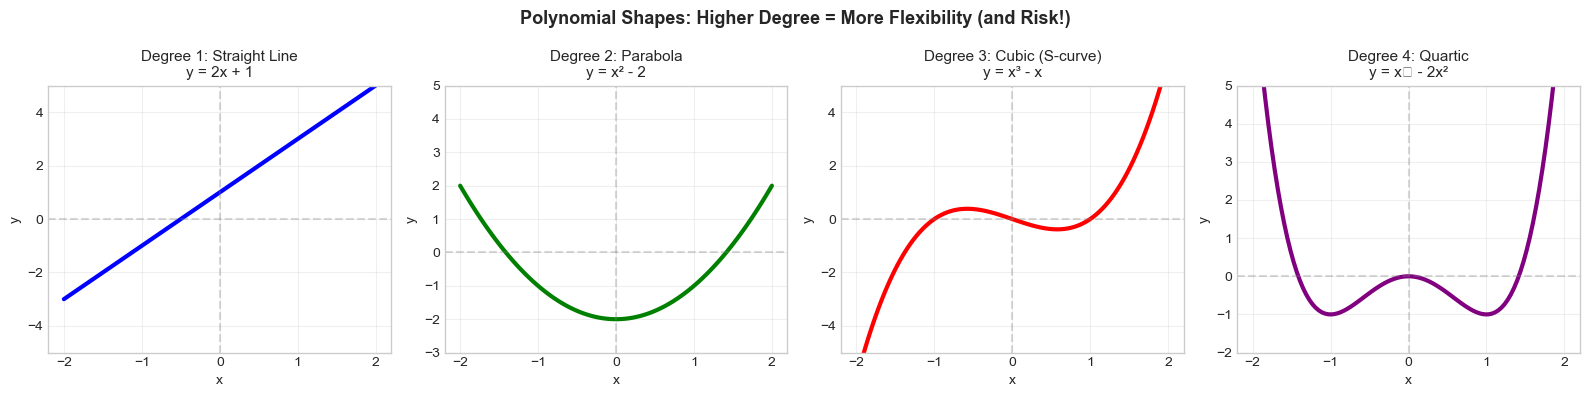

Notice: Each degree adds one more possible 'bend' to the curve!


In [33]:
# Let's visualize what different polynomial degrees look like
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

x = np.linspace(-2, 2, 100)

# Degree 1: Straight line
axes[0].plot(x, 2*x + 1, 'b-', linewidth=3)
axes[0].set_title('Degree 1: Straight Line\ny = 2x + 1', fontsize=11)
axes[0].set_ylim(-5, 5)
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# Degree 2: Parabola
axes[1].plot(x, x**2 - 2, 'g-', linewidth=3)
axes[1].set_title('Degree 2: Parabola\ny = x² - 2', fontsize=11)
axes[1].set_ylim(-3, 5)
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# Degree 3: Cubic (S-curve)
axes[2].plot(x, x**3 - x, 'r-', linewidth=3)
axes[2].set_title('Degree 3: Cubic (S-curve)\ny = x³ - x', fontsize=11)
axes[2].set_ylim(-5, 5)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[2].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

# Degree 4: Quartic (W-shape possible)
axes[3].plot(x, x**4 - 2*x**2, 'purple', linewidth=3)
axes[3].set_title('Degree 4: Quartic\ny = x⁴ - 2x²', fontsize=11)
axes[3].set_ylim(-2, 5)
axes[3].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[3].axvline(x=0, color='gray', linestyle='--', alpha=0.3)

for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.grid(True, alpha=0.3)

plt.suptitle('Polynomial Shapes: Higher Degree = More Flexibility (and Risk!)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice: Each degree adds one more possible 'bend' to the curve!")

In [34]:
# Polynomial Regression with Degree 2

# Step 1: Create polynomial features (on scaled data)
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly2 = poly2.fit_transform(X_train_car_scaled)
X_test_poly2 = poly2.transform(X_test_car_scaled)

# Step 2: Train a linear regression on the transformed features
model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train_car)

# Step 3: Evaluate
y_pred_poly2 = model_poly2.predict(X_test_poly2)
r2_poly2 = r2_score(y_test_car, y_pred_poly2)
rmse_poly2 = np.sqrt(mean_squared_error(y_test_car, y_pred_poly2))

print(f"Polynomial Regression (Degree 2):")
print(f"R² Score: {r2_poly2:.4f}")
print(f"RMSE: ${rmse_poly2:,.2f}")
print(f"\nImprovement over linear: R² increased by {r2_poly2 - r2_car_linear:.4f}!")

Polynomial Regression (Degree 2):
R² Score: 0.9420
RMSE: $1,569.78

Improvement over linear: R² increased by 0.2089!


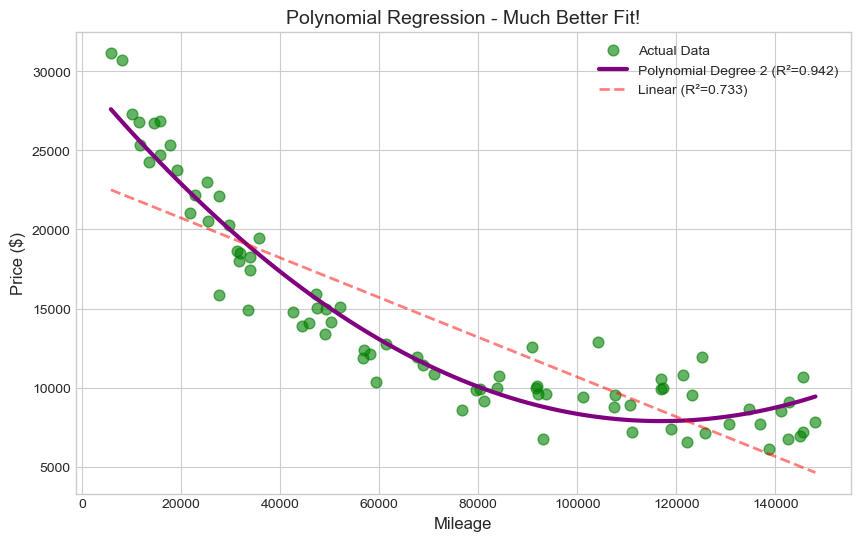

The curve follows the natural depreciation pattern!


In [35]:
# Visualize degree 2 polynomial fit
plt.figure(figsize=(10, 6))

plt.scatter(df_cars['Mileage'], df_cars['Price'], color='green', alpha=0.6, s=60, label='Actual Data')

# Polynomial prediction curve
X_line_poly2 = poly2.transform(X_line_car_scaled)
y_line_poly2 = model_poly2.predict(X_line_poly2)

plt.plot(X_line_car, y_line_poly2, color='purple', linewidth=3, label=f'Polynomial Degree 2 (R²={r2_poly2:.3f})')
plt.plot(X_line_car, y_line_car, color='red', linewidth=2, linestyle='--', alpha=0.5, label=f'Linear (R²={r2_car_linear:.3f})')

plt.xlabel('Mileage', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Polynomial Regression - Much Better Fit!', fontsize=14)
plt.legend()
plt.show()

print("The curve follows the natural depreciation pattern!")

In [36]:
# Let's also try degree 3
poly3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly3 = poly3.fit_transform(X_train_car_scaled)
X_test_poly3 = poly3.transform(X_test_car_scaled)

model_poly3 = LinearRegression()
model_poly3.fit(X_train_poly3, y_train_car)

y_pred_poly3 = model_poly3.predict(X_test_poly3)
r2_poly3 = r2_score(y_test_car, y_pred_poly3)
rmse_poly3 = np.sqrt(mean_squared_error(y_test_car, y_pred_poly3))

# Compare all three
print("=" * 50)
print("POLYNOMIAL REGRESSION COMPARISON")
print("=" * 50)
print(f"Linear (Degree 1):  R² = {r2_car_linear:.4f}, RMSE = ${rmse_car_linear:,.2f}")
print(f"Polynomial Deg 2:   R² = {r2_poly2:.4f}, RMSE = ${rmse_poly2:,.2f}")
print(f"Polynomial Deg 3:   R² = {r2_poly3:.4f}, RMSE = ${rmse_poly3:,.2f}")
print("=" * 50)

POLYNOMIAL REGRESSION COMPARISON
Linear (Degree 1):  R² = 0.7330, RMSE = $3,366.99
Polynomial Deg 2:   R² = 0.9420, RMSE = $1,569.78
Polynomial Deg 3:   R² = 0.9630, RMSE = $1,253.33


---
# Part 3: Overfitting vs Underfitting
## The Goldilocks Problem of Machine Learning

You learned about overfitting and underfitting conceptually a few days ago. Now we're going to **see it in action** and learn how to **detect it** using data.

> **Quick Refresher:**
> - **Underfitting** = Model is too simple, misses important patterns
> - **Overfitting** = Model is too complex, memorizes noise instead of learning patterns
> - **Just Right** = Model captures the real patterns and generalizes to new data

> **Analogy:** Imagine studying for an exam:
> - **Underfitting** = Barely skimming the textbook - you miss important concepts
> - **Overfitting** = Memorizing every word including typos and page numbers - you can't answer questions phrased differently
> - **Just Right** = Understanding core concepts well enough to apply them to new problems

### The Big Question: How Do We Know If Our Model Is Overfitting?

Here's the key insight: **We can't tell just by looking at training performance!**

An overfit model looks GREAT on training data (that's the problem - it memorized it). The only way to detect overfitting is to check how the model performs on **data it has never seen before** - the test set.

### Our Strategy: Compare Training vs Test Performance

We're going to:
1. **Try different model complexities** (polynomial degrees 1 through 15)
2. **For each one, measure error on BOTH training and test data**
3. **Plot both errors and look for the pattern**

This is one of the most important techniques in machine learning - and you'll use it constantly!

### What Should We Expect to See?

Before we run the experiment, let's predict what will happen:

**Training Error:**
- As we increase polynomial degree, the model gets more flexible
- More flexibility = can fit the training data better
- So training error should **keep going down** as degree increases

**Test Error:**
- At first, higher degree helps (captures the real curve better)
- But at some point, the model starts fitting **noise** in the training data
- Noise is random - it won't be the same in the test data!
- So test error should **go down, then back up**

**The Pattern of Overfitting:**
```
Training error: ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ (keeps decreasing)
Test error:     ↓ ↓ ↓ ↑ ↑ ↑ ↑ ↑ (decreases then increases!)
                    ^
              Sweet spot here!
```

Let's see if this is what actually happens...

> **Consulting Story:** I once worked with a healthcare startup that built a model to predict patient no-shows. They included every possible feature - weather, day of week, distance from clinic, historical patterns, even lunar phases (yes, really). The model was 98% accurate on their training data. When deployed on new patients? It dropped to 60%. Classic overfitting. They'd memorized the noise in their training data. We stripped it back to the 5 most meaningful features and got stable 78% accuracy that actually held up in production.
>
> **The lesson:** Always check test performance, not just training performance!

### Let's Run the Experiment!

We'll train 15 different polynomial models (degree 1 through 15) and measure the error of each one on **both** the training data and the test data.

In [37]:
# Let's demonstrate overfitting with polynomial regression
# We'll try degrees 1-15 and see what happens

degrees = list(range(1, 16))  # 1 through 15
train_mse = []
test_mse = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_p = poly.fit_transform(X_train_car_scaled)
    X_test_p = poly.transform(X_test_car_scaled)
    
    # Train model
    model = LinearRegression()
    model.fit(X_train_p, y_train_car)
    
    # Calculate MSE on both train and test
    y_train_pred = model.predict(X_train_p)
    y_test_pred = model.predict(X_test_p)
    
    train_error = mean_squared_error(y_train_car, y_train_pred)
    test_error = mean_squared_error(y_test_car, y_test_pred)
    
    train_mse.append(train_error)
    test_mse.append(test_error)

# Print summary for key degrees
print("Key results:")
for d in [1, 2, 3, 5, 10, 15]:
    idx = d - 1  # Convert degree to index
    print(f"Degree {d:2d}: Train MSE = {train_mse[idx]:,.0f}, Test MSE = {test_mse[idx]:,.0f}")

Key results:
Degree  1: Train MSE = 9,840,206, Test MSE = 11,336,620
Degree  2: Train MSE = 3,415,549, Test MSE = 2,464,208
Degree  3: Train MSE = 2,126,466, Test MSE = 1,570,831
Degree  5: Train MSE = 2,071,386, Test MSE = 1,877,007
Degree 10: Train MSE = 2,027,652, Test MSE = 1,908,379
Degree 15: Train MSE = 1,929,069, Test MSE = 9,174,388


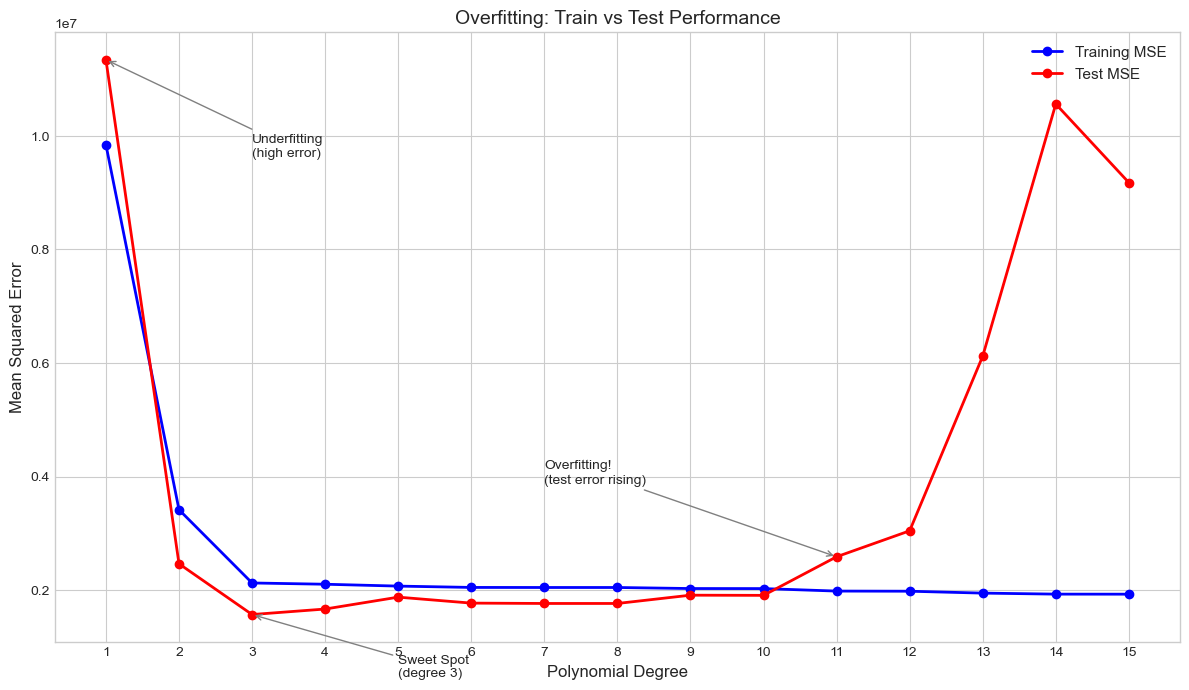

Best polynomial degree: 3 (lowest test MSE)

Notice: Training MSE keeps going DOWN, but test MSE goes UP after degree ~3!


In [38]:
# Visualize the train vs test MSE
plt.figure(figsize=(12, 7))

plt.plot(degrees, train_mse, 'b-o', linewidth=2, markersize=6, label='Training MSE')
plt.plot(degrees, test_mse, 'r-o', linewidth=2, markersize=6, label='Test MSE')

plt.xlabel('Polynomial Degree', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Overfitting: Train vs Test Performance', fontsize=14)
plt.legend(fontsize=11)
plt.xticks(degrees)  # Show all degree numbers on x-axis

# Find the actual sweet spot (lowest test MSE)
best_degree = degrees[test_mse.index(min(test_mse))]

# Add annotations - pointing to the actual data
plt.annotate('Underfitting\n(high error)', xy=(1, test_mse[0]), xytext=(3, test_mse[0] * 0.85),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
plt.annotate(f'Sweet Spot\n(degree {best_degree})', xy=(best_degree, test_mse[best_degree-1]), 
             xytext=(5, min(test_mse) * 0.3),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
plt.annotate('Overfitting!\n(test error rising)', xy=(11, test_mse[10]), xytext=(7, test_mse[10] * 1.5),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

print(f"Best polynomial degree: {best_degree} (lowest test MSE)")
print(f"\nNotice: Training MSE keeps going DOWN, but test MSE goes UP after degree ~{best_degree}!")

### 🔑 Understanding What Just Happened

**Let's break down what we just saw:**

1. **We trained 15 different models** - each with a different polynomial degree (1, 2, 3, ... 15)

2. **For each model, we calculated error on TWO datasets:**
   - Training data (blue line) - the data the model learned from
   - Test data (red line) - data the model has NEVER seen

3. **We plotted both errors to see the pattern**

---

### How to Read This Chart (You'll See This Pattern A LOT!)

| Region | Training Error | Test Error | What's Happening | Diagnosis |
|--------|---------------|------------|------------------|-----------|
| **Left side** (low degree) | High | High | Model too simple to capture pattern | **Underfitting** |
| **Middle** (sweet spot) | Low | Low | Model captures real pattern | **Good fit!** |
| **Right side** (high degree) | Very low | Goes back up! | Model memorizing noise | **Overfitting** |

---

### The Key Signal: Watch the GAP!

```
          Training Error    Test Error
               ↓                ↓
Good fit:     LOW              LOW         (small gap ✓)
Overfitting:  VERY LOW         HIGH        (big gap ✗)
```

**When training error is much lower than test error, your model is overfitting!**

The model is essentially "cheating" - it memorized the training data but can't generalize to new data.

---

### Why This Matters for Your ML Career

This visualization pattern appears EVERYWHERE in machine learning:

- **Polynomial degree** (what we just did)
- **Tree depth** in decision trees
- **Number of epochs** when training neural networks
- **Regularization strength** (alpha in Ridge/Lasso)
- **Number of features** in your model

**Every time you tune a hyperparameter, you should make a chart like this!**

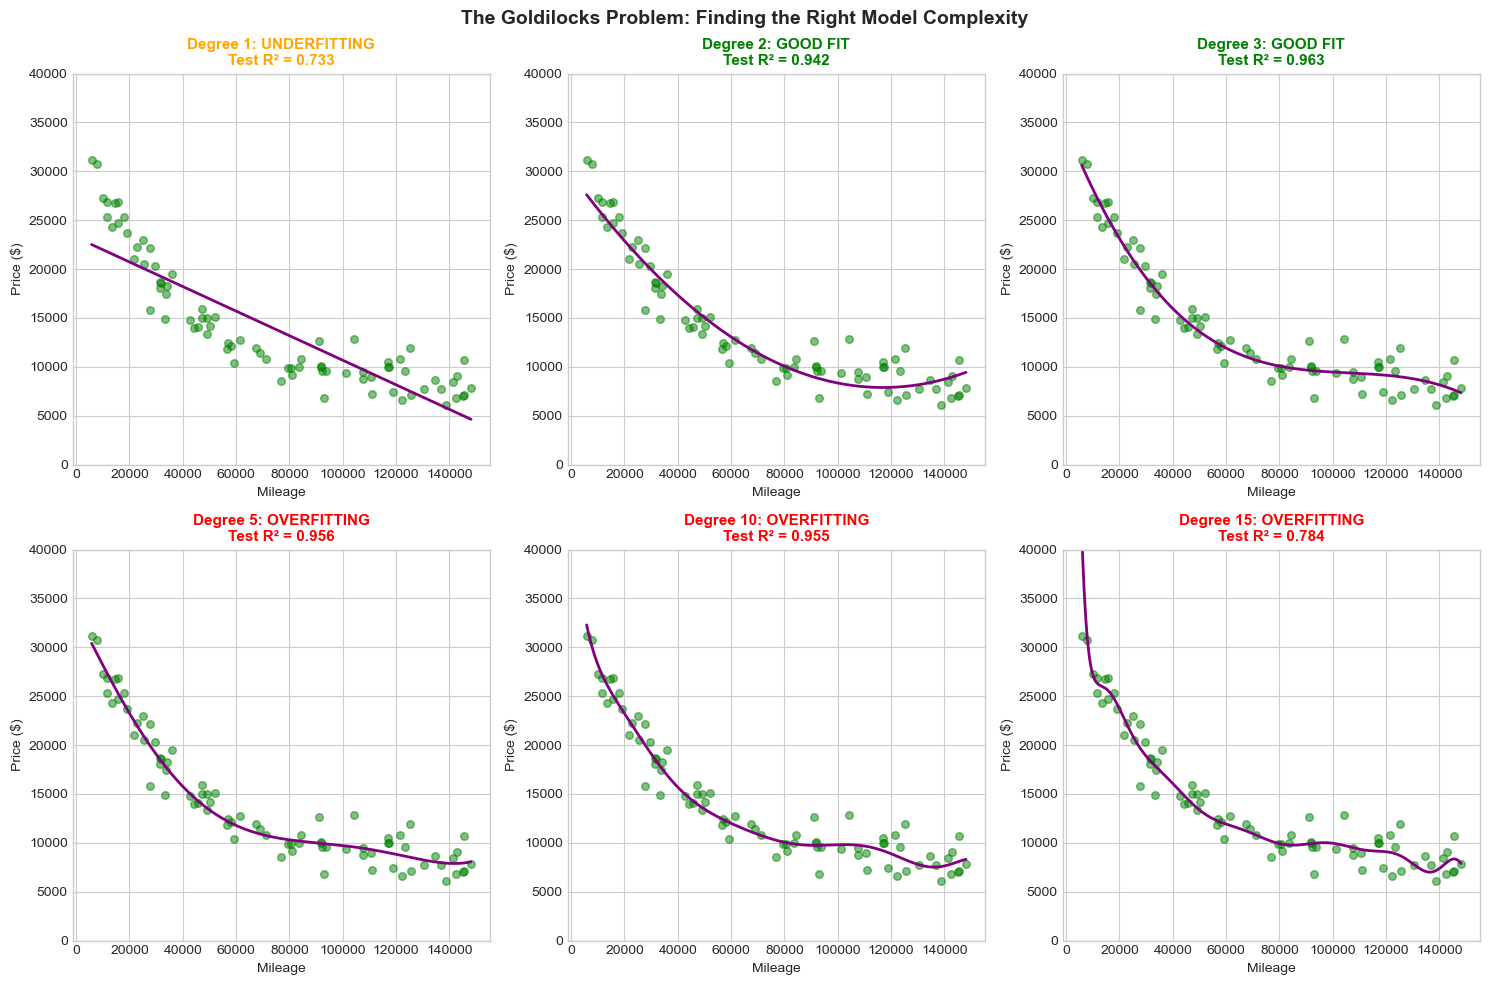

Notice how the high-degree polynomials get 'wiggly' - they're fitting the noise!


In [23]:
# Visualize the actual curves at different degrees
# We'll show a representative subset to see the progression
viz_degrees = [1, 2, 3, 5, 10, 15]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Create smooth x values for plotting
X_plot = np.linspace(df_cars['Mileage'].min(), df_cars['Mileage'].max(), 300).reshape(-1, 1)
X_plot_scaled = scaler_car.transform(X_plot)

for idx, degree in enumerate(viz_degrees):
    ax = axes[idx]
    
    # Create and fit model
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_p = poly.fit_transform(X_train_car_scaled)
    X_test_p = poly.transform(X_test_car_scaled)
    
    model = LinearRegression()
    model.fit(X_train_p, y_train_car)
    
    # Plot data
    ax.scatter(df_cars['Mileage'], df_cars['Price'], color='green', alpha=0.5, s=30)
    
    # Plot curve
    X_plot_poly = poly.transform(X_plot_scaled)
    y_plot = model.predict(X_plot_poly)
    
    ax.plot(X_plot, y_plot, color='purple', linewidth=2)
    
    # Get test score for title
    test_r2 = model.score(X_test_p, y_test_car)
    
    # Determine fit quality based on our earlier analysis
    if degree == 1:
        fit_type = "UNDERFITTING"
        title_color = 'orange'
    elif degree <= 3:
        fit_type = "GOOD FIT"
        title_color = 'green'
    else:
        fit_type = "OVERFITTING"
        title_color = 'red'
    
    ax.set_title(f'Degree {degree}: {fit_type}\nTest R² = {test_r2:.3f}', 
                 fontsize=11, color=title_color, fontweight='bold')
    ax.set_xlabel('Mileage')
    ax.set_ylabel('Price ($)')
    ax.set_ylim(0, 40000)

plt.suptitle('The Goldilocks Problem: Finding the Right Model Complexity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice how the high-degree polynomials get 'wiggly' - they're fitting the noise!")

---
# Part 4: Decision Tree Regression
## A Completely Different Approach

Decision trees don't assume ANY specific relationship shape - they learn it from the data!

> **Analogy:** Decision trees work like a game of 20 questions, or like those medical symptom checkers: "Is square footage > 1800? Yes → Is bedrooms > 3? No → Predicted price: \$275,000." Each split divides the data based on the most informative question to ask next.

### Decision Tree Terminology

Before we dive in, let's learn the vocabulary:

```
                    [Root Node]           ← The TOP of the tree (first question)
                    /          \
                   /            \
           [Internal Node]    [Internal Node]   ← Nodes in the MIDDLE (more questions)
              /      \            /      \
             /        \          /        \
        [Leaf]     [Leaf]    [Leaf]     [Leaf]  ← The BOTTOM (final predictions)
```

| Term | What It Is | Example |
|------|------------|----------|
| **Root Node** | The very first decision at the top | "Is SquareFootage > 1800?" |
| **Internal Node** | A decision point in the middle | "Is Bedrooms > 3?" |
| **Leaf Node** | The end points - where predictions happen | "Predict \$285,000" |
| **Branch** | The path from one node to another | The line connecting nodes |
| **Depth** | How many levels from root to deepest leaf | A depth-3 tree has 3 levels of questions |

**Key insight:** Every prediction follows a path from root → through internal nodes → to a leaf. The leaf gives the final answer!

### How Does a Decision Tree Actually Learn?

The algorithm builds the tree by asking: **"What's the best question to split the data?"**

**Step-by-step process:**

1. **Start with all data at the root** - Calculate the average target value (e.g., average house price = \$287,000)

2. **Try every possible split** - For each feature, try splitting at different thresholds:
   - "What if we split at SquareFootage > 1500?"
   - "What if we split at SquareFootage > 1800?"
   - "What if we split at Bedrooms > 3?"

3. **Pick the split that reduces error the most** - The algorithm measures how much each split reduces the variance (spread) in the target values. The best split creates groups where houses within each group have similar prices.

4. **Repeat recursively** - Each branch becomes its own mini-problem. Keep splitting until:
   - You reach `max_depth` (we'll use 3)
   - A node has too few samples (`min_samples_split`)
   - The node is "pure" enough

**For regression, the prediction at each leaf is simply the AVERAGE of all training samples that ended up there.**

### Why Can Trees Look Different?

An important thing to understand: **there's no single "correct" tree for a dataset!**

The tree structure depends on:
- **`max_depth`** - How many levels of questions to ask
- **`min_samples_split`** - Minimum samples needed to create a new split
- **`min_samples_leaf`** - Minimum samples required in each final leaf
- **The data itself** - Different training samples → different trees!

Let's see this in action by training trees with different `max_depth` values...

### The `max_depth` Parameter

This is the most important hyperparameter for decision trees:

| max_depth | What Happens | Risk |
|-----------|--------------|------|
| Too shallow (1-2) | Very simple rules, misses patterns | **Underfitting** |
| Just right (3-5) | Captures main patterns, generalizes well | Good! |
| Too deep (10+) | Memorizes every training sample | **Overfitting** |

> **Health Tech Story:** Clinical decision support systems often use decision trees because doctors can actually understand and trust them. When a model says "this patient is high risk," physicians want to know WHY. A decision tree shows the exact logic: "Age > 65 AND has diabetes AND blood pressure > 140 → High Risk." That transparency matters when lives are on the line. This is called "interpretability" or "explainability" - and it's increasingly required by healthcare regulations.

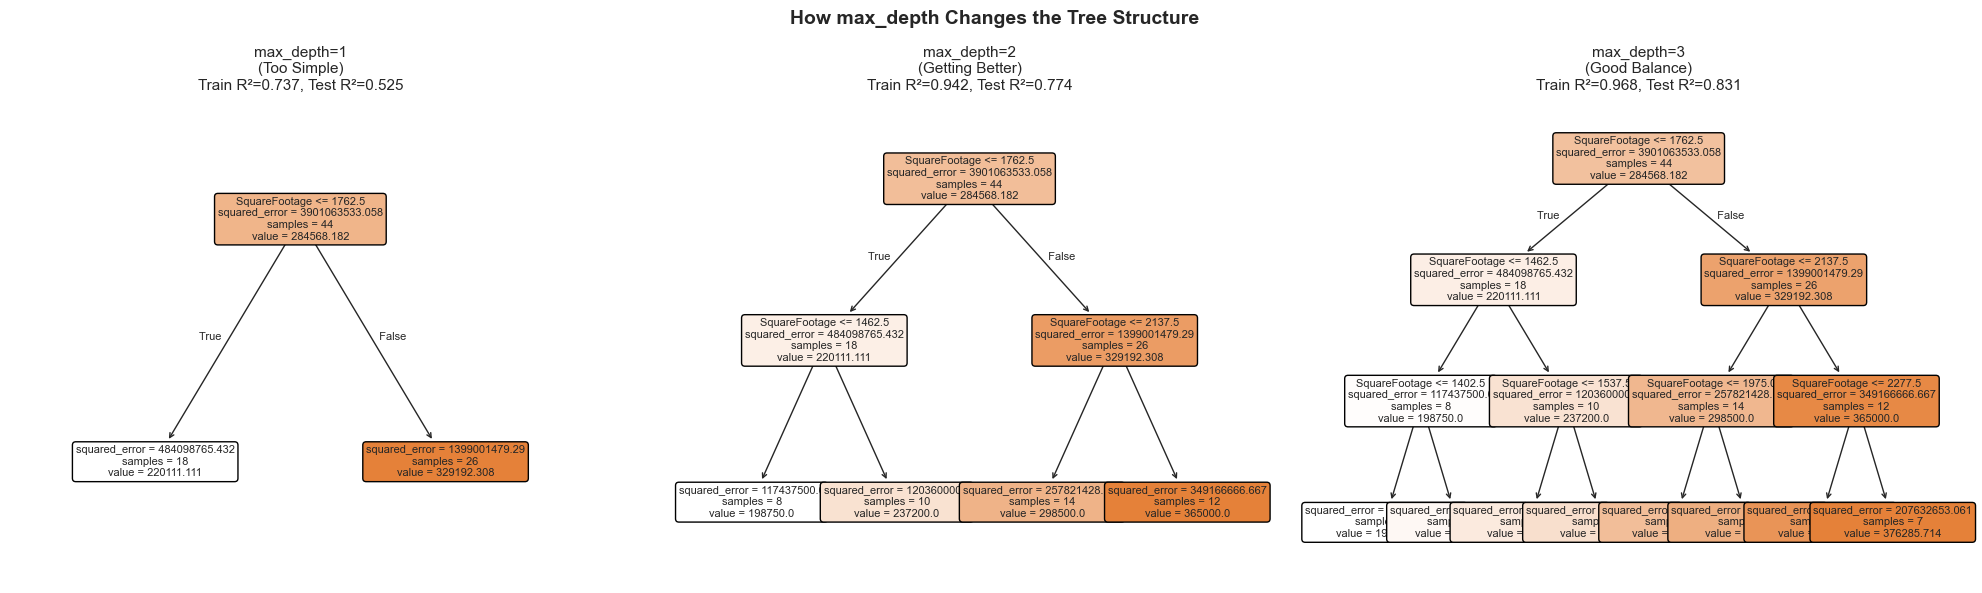

Notice:
  - Depth 1: Only 1 question (root) → 2 leaves → very simple predictions
  - Depth 2: Root + 2 more questions → 4 leaves → captures more nuance
  - Depth 3: Even more questions → up to 8 leaves → more detailed predictions

But be careful! Too deep = overfitting (memorizing training data)


In [39]:
# Let's see how max_depth changes the tree structure!
# We'll train 3 trees with different depths and compare them

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

depths = [1, 2, 3]
titles = ['max_depth=1\n(Too Simple)', 'max_depth=2\n(Getting Better)', 'max_depth=3\n(Good Balance)']

for ax, depth, title in zip(axes, depths, titles):
    # Train a tree with this depth
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train_m, y_train_m)
    
    # Calculate scores
    train_r2 = tree.score(X_train_m, y_train_m)
    test_r2 = tree.score(X_test_m, y_test_m)
    
    # Plot the tree
    plot_tree(tree, 
              feature_names=['SquareFootage', 'Bedrooms'],
              filled=True,
              rounded=True,
              fontsize=8,
              ax=ax)
    
    ax.set_title(f'{title}\nTrain R²={train_r2:.3f}, Test R²={test_r2:.3f}', fontsize=11)

plt.suptitle('How max_depth Changes the Tree Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice:")
print("  - Depth 1: Only 1 question (root) → 2 leaves → very simple predictions")
print("  - Depth 2: Root + 2 more questions → 4 leaves → captures more nuance")
print("  - Depth 3: Even more questions → up to 8 leaves → more detailed predictions")
print("\nBut be careful! Too deep = overfitting (memorizing training data)")

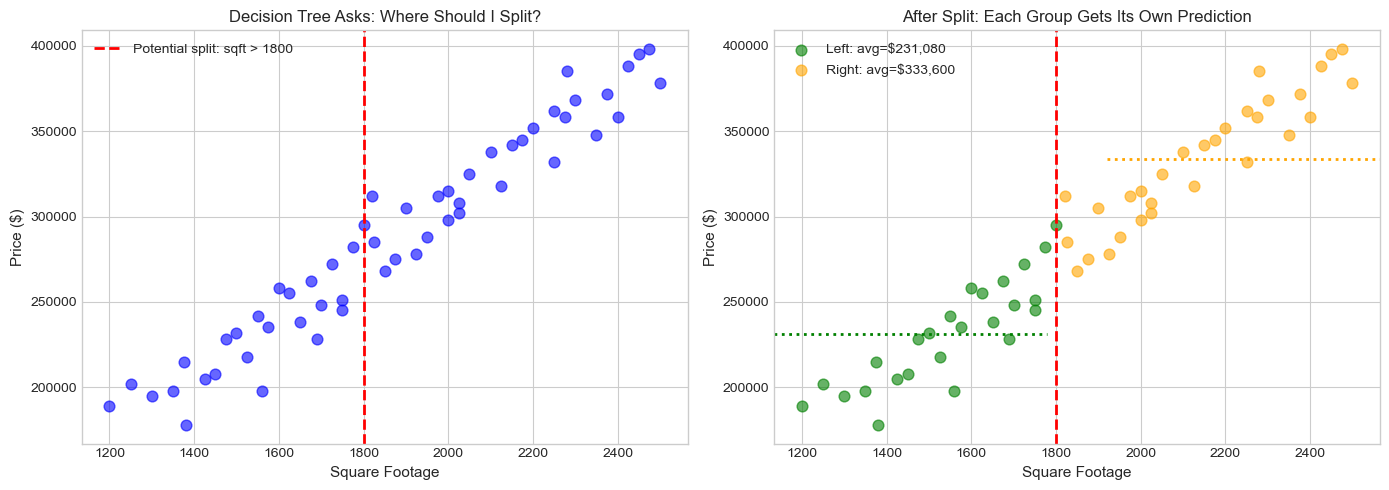

If we split at SquareFootage > 1800:
  Left group (≤1800 sqft):  25 houses, avg price = $231,080
  Right group (>1800 sqft): 30 houses, avg price = $333,600

The tree then asks: 'Can I split each group further to get even better predictions?'


In [40]:
# Let's see how a decision tree thinks about splitting
# We'll look at the housing data and see why it might split at certain points

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Show the data with a potential split
ax1 = axes[0]
ax1.scatter(df_housing['SquareFootage'], df_housing['Price'], c='blue', alpha=0.6, s=60)
ax1.axvline(x=1800, color='red', linestyle='--', linewidth=2, label='Potential split: sqft > 1800')
ax1.set_xlabel('Square Footage', fontsize=11)
ax1.set_ylabel('Price ($)', fontsize=11)
ax1.set_title('Decision Tree Asks: Where Should I Split?', fontsize=12)
ax1.legend()

# Calculate averages for each side of the split
left_prices = df_housing[df_housing['SquareFootage'] <= 1800]['Price']
right_prices = df_housing[df_housing['SquareFootage'] > 1800]['Price']

# Right plot: Show the result of splitting
ax2 = axes[1]
ax2.scatter(df_housing[df_housing['SquareFootage'] <= 1800]['SquareFootage'], 
            left_prices, c='green', alpha=0.6, s=60, label=f'Left: avg=${left_prices.mean():,.0f}')
ax2.scatter(df_housing[df_housing['SquareFootage'] > 1800]['SquareFootage'], 
            right_prices, c='orange', alpha=0.6, s=60, label=f'Right: avg=${right_prices.mean():,.0f}')
ax2.axvline(x=1800, color='red', linestyle='--', linewidth=2)
ax2.axhline(y=left_prices.mean(), color='green', linestyle=':', linewidth=2, xmax=0.45)
ax2.axhline(y=right_prices.mean(), color='orange', linestyle=':', linewidth=2, xmin=0.55)
ax2.set_xlabel('Square Footage', fontsize=11)
ax2.set_ylabel('Price ($)', fontsize=11)
ax2.set_title('After Split: Each Group Gets Its Own Prediction', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()

print(f"If we split at SquareFootage > 1800:")
print(f"  Left group (≤1800 sqft):  {len(left_prices)} houses, avg price = ${left_prices.mean():,.0f}")
print(f"  Right group (>1800 sqft): {len(right_prices)} houses, avg price = ${right_prices.mean():,.0f}")
print(f"\nThe tree then asks: 'Can I split each group further to get even better predictions?'")

In [41]:
# Train a decision tree on the housing data
# Using max_depth=3 to keep it readable

tree_model = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_model.fit(X_train_m, y_train_m)  # Using the multiple features (sqft + bedrooms)

print("Decision Tree trained!")
print(f"Tree depth: {tree_model.get_depth()}")
print(f"Number of leaves (final predictions): {tree_model.get_n_leaves()}")

Decision Tree trained!
Tree depth: 3
Number of leaves (final predictions): 8


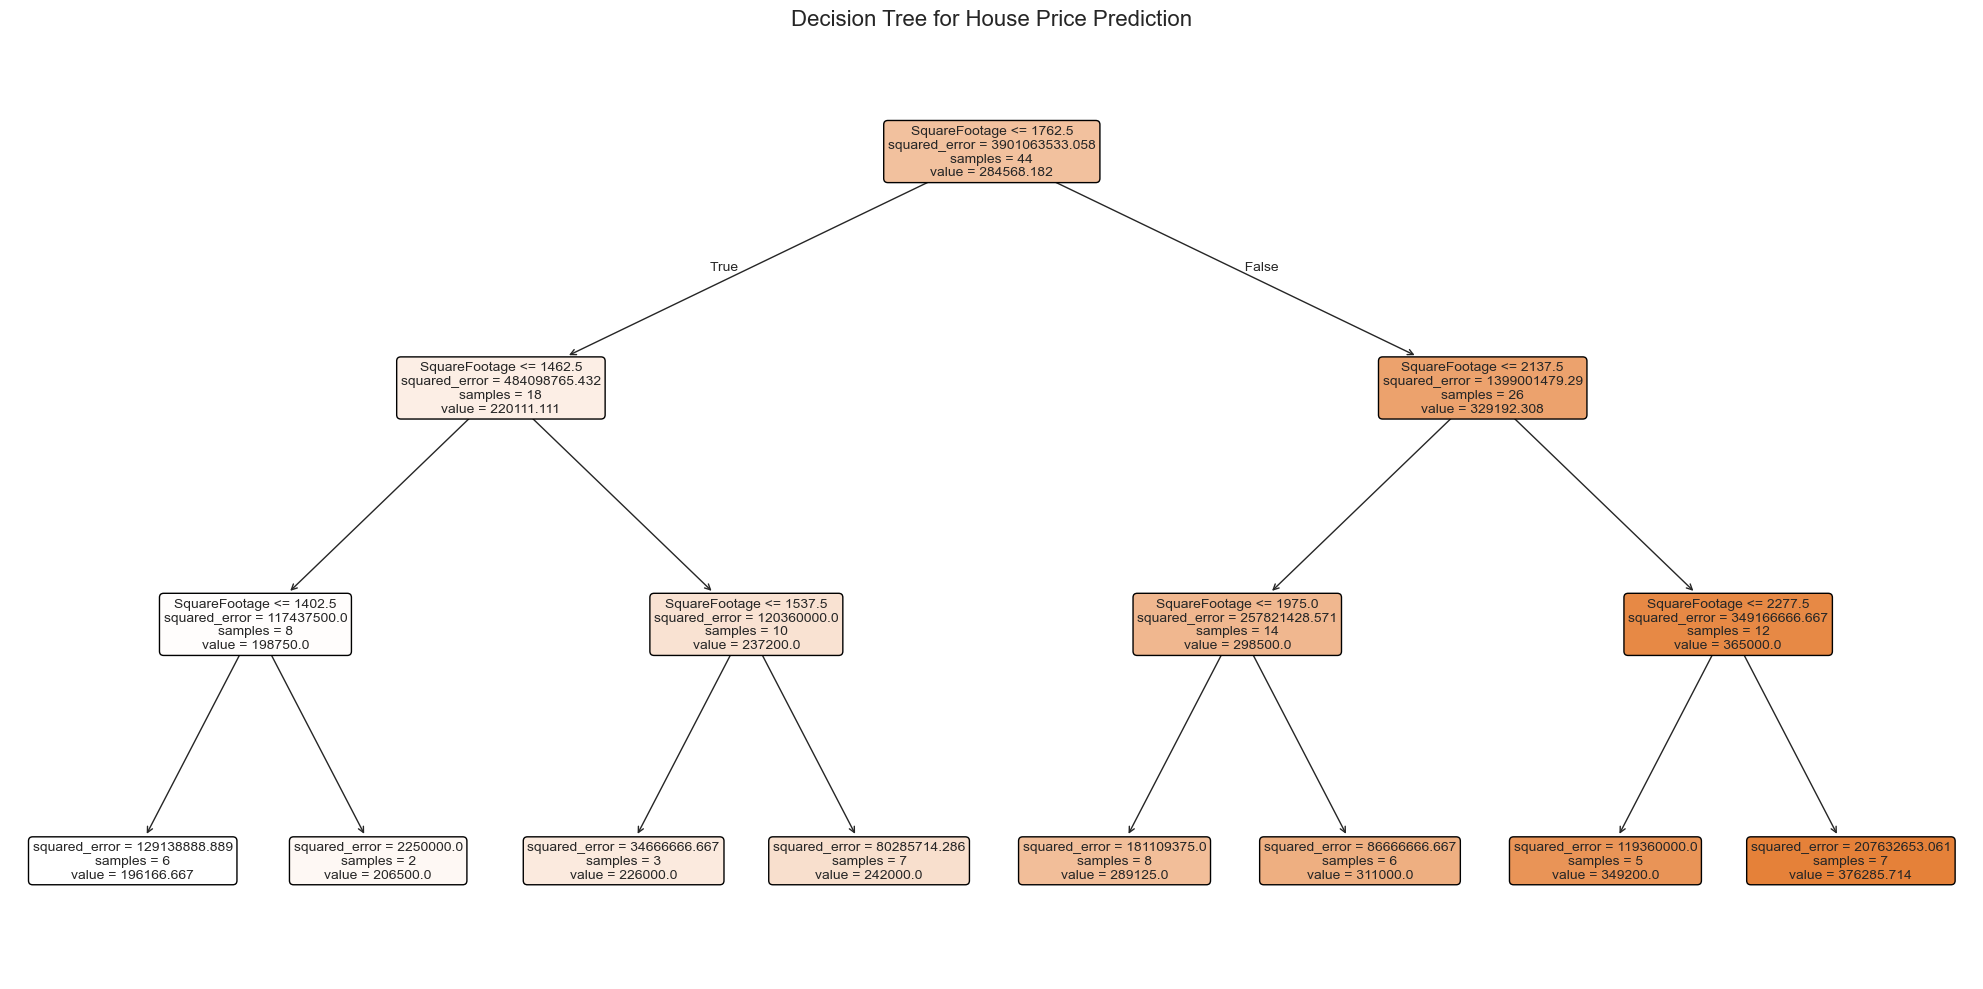


How to read this tree:
- Start at the top (root node)
- If the condition is TRUE, go LEFT
- If the condition is FALSE, go RIGHT
- The 'value' at each leaf is the predicted price


In [42]:
# THE BIG VISUAL PAYOFF - See the actual tree!
plt.figure(figsize=(20, 10))

plot_tree(tree_model, 
          feature_names=['SquareFootage', 'Bedrooms'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title('Decision Tree for House Price Prediction', fontsize=16)
plt.tight_layout()
plt.show()

print("\nHow to read this tree:")
print("- Start at the top (root node)")
print("- If the condition is TRUE, go LEFT")
print("- If the condition is FALSE, go RIGHT")
print("- The 'value' at each leaf is the predicted price")

### How to Read This Tree

Let's break down what you're seeing:

**Each box (node) contains:**
- **Condition** (top line): The yes/no question (e.g., `SquareFootage <= 1837.5`)
- **squared_error**: How spread out the prices are in this group
- **samples**: How many houses from training data are in this node
- **value**: The predicted price (average of all samples in this node)

**The colors:**
- **Darker color** = More confident prediction (samples have similar values)
- **Lighter color** = Less confident (more spread in the data)

**Navigation:**
- If the condition is **TRUE** → go **LEFT**
- If the condition is **FALSE** → go **RIGHT**

**Leaf nodes** (bottom boxes with no children) give the final prediction!

In [44]:
# Let's trace through a prediction manually!
print("="*50)
print("Let's predict the price for a house with:")
print("  - 2000 Square Feet")
print("  - 4 Bedrooms")
print("="*50)
print("\nFollow along in the tree diagram above!")
print("\nThe tree asks yes/no questions to narrow down the price.")

# Make the actual prediction
sample_house = [[2000, 4]]
predicted_price = tree_model.predict(sample_house)

print(f"\nTree's prediction: ${predicted_price[0]:,.2f}")

Let's predict the price for a house with:
  - 2000 Square Feet
  - 4 Bedrooms

Follow along in the tree diagram above!

The tree asks yes/no questions to narrow down the price.

Tree's prediction: $311,000.00


In [45]:
# Evaluate the decision tree
y_pred_tree = tree_model.predict(X_test_m)

r2_tree = r2_score(y_test_m, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test_m, y_pred_tree))

print("=" * 50)
print("DECISION TREE vs LINEAR MODELS (Housing Data)")
print("=" * 50)
print(f"Simple Linear:      R² = {r2_simple:.4f}, RMSE = ${rmse_simple:,.2f}")
print(f"Multiple Linear:    R² = {r2_multi:.4f}, RMSE = ${rmse_multi:,.2f}")
print(f"Decision Tree:      R² = {r2_tree:.4f}, RMSE = ${rmse_tree:,.2f}")
print("=" * 50)
print("\nDecision trees trade some accuracy for interpretability.")
print("You can actually SEE why the model made each prediction!")

DECISION TREE vs LINEAR MODELS (Housing Data)
Simple Linear:      R² = 0.9211, RMSE = $15,647.35
Multiple Linear:    R² = 0.9244, RMSE = $15,319.59
Decision Tree:      R² = 0.8313, RMSE = $22,885.68

Decision trees trade some accuracy for interpretability.
You can actually SEE why the model made each prediction!


---
## 🎯 Your Turn: Decision Tree on Car Data

Build a decision tree to predict **car prices** from mileage!

**Your Task:**
1. Create a DecisionTreeRegressor with max_depth=3
2. Train it on the car data
3. Visualize the tree and evaluate performance

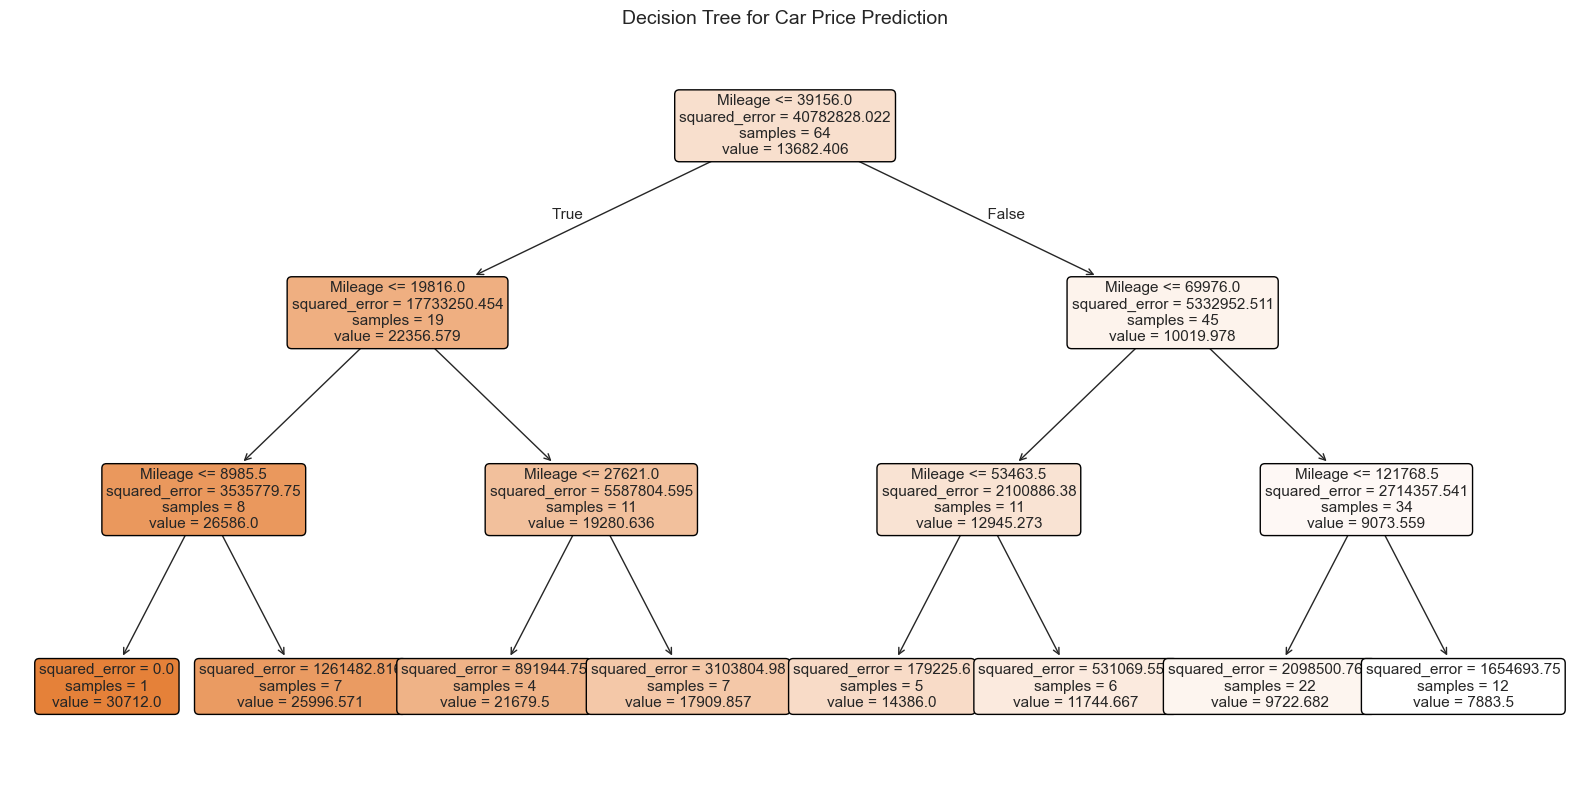

YOUR RESULTS: Decision Tree on Car Data
Linear Regression R²:  0.7330
Polynomial (Deg 2) R²: 0.9420
Decision Tree R²:      0.9571

Which model works best for the curved car data?


In [49]:
# 🎯 PRACTICE: Decision Tree on Car Data
# Build a decision tree to predict car prices from mileage

# Step 1: Create the decision tree model
# YOUR CODE HERE - Create a DecisionTreeRegressor with max_depth=3, random_state=42
tree_car = DecisionTreeRegressor(max_depth=3, random_state=42)


# Step 2: Train the model on car data (use X_train_car, y_train_car)
# Note: Decision trees don't need scaled data!
# YOUR CODE HERE - Fit the model
tree_car.fit(X_train_car, y_train_car)


# Step 3: Visualize the tree
plt.figure(figsize=(16, 8))
plot_tree(tree_car, 
          feature_names=['Mileage'],
          filled=True,
          rounded=True,
          fontsize=11)
plt.title('Decision Tree for Car Price Prediction', fontsize=14)
plt.tight_layout()
plt.show()

# Step 4: Evaluate
y_pred_tree_car = tree_car.predict(X_test_car)
r2_tree_car = r2_score(y_test_car, y_pred_tree_car)

print("="*50)
print("YOUR RESULTS: Decision Tree on Car Data")
print("="*50)
print(f"Linear Regression R²:  {r2_car_linear:.4f}")
print(f"Polynomial (Deg 2) R²: {r2_poly2:.4f}")
print(f"Decision Tree R²:      {r2_tree_car:.4f}")
print("="*50)
print("\nWhich model works best for the curved car data?")

---
# Part 5: Regularization
## Adding Guardrails to Prevent Overfitting

> **Analogy:** Imagine you're packing for a trip with a weight limit (regularization):
> - **Ridge** is like compressing everything a little - you take some of each item but less of each
> - **Lasso** is like making hard choices - some items stay home entirely
> - **ElasticNet** lets you do both - compress some things and leave others behind

> **Consulting Story:** In healthcare analytics, we often have hundreds of potential predictors - lab values, vitals, medications, diagnoses. Lasso regression became my go-to tool because it automatically identifies which features actually matter. For one readmission prediction project, we started with 200+ features. Lasso zeroed out all but 23 of them, and the simpler model actually performed BETTER on new patients while being much easier to implement in the hospital's system.

In [31]:
# Let's see regularization in action using our overfit polynomial model

# Create high-degree polynomial features (prone to overfitting)
# We use degree 15 to ensure we have MORE features than samples can support
# This creates a situation where regularization will clearly help
poly_high = PolynomialFeatures(degree=15, include_bias=False)
X_train_high = poly_high.fit_transform(X_train_car_scaled)
X_test_high = poly_high.transform(X_test_car_scaled)

print(f"Original features: 1")
print(f"Polynomial features (degree 15): {X_train_high.shape[1]}")
print(f"Training samples: {X_train_car_scaled.shape[0]}")
print("\nWith 15 features and only ~64 samples, we're setting up for overfitting!")
print("(Rule of thumb: you want at least 10-20 samples per feature)")

Original features: 1
Polynomial features (degree 15): 15
Training samples: 64

With 15 features and only ~64 samples, we're setting up for overfitting!
(Rule of thumb: you want at least 10-20 samples per feature)


In [32]:
# Regular linear regression (no regularization) - will overfit!
model_no_reg = LinearRegression()
model_no_reg.fit(X_train_high, y_train_car)

r2_no_reg_train = model_no_reg.score(X_train_high, y_train_car)
r2_no_reg_test = model_no_reg.score(X_test_high, y_test_car)

print("No Regularization (Degree 15 Polynomial):")
print(f"  Train R²: {r2_no_reg_train:.4f}")
print(f"  Test R²:  {r2_no_reg_test:.4f}")
print(f"  Gap:      {r2_no_reg_train - r2_no_reg_test:.4f}")
print("\nBig gap between train and test = OVERFITTING!")

No Regularization (Degree 15 Polynomial):
  Train R²: 0.9527
  Test R²:  0.7839
  Gap:      0.1688

Big gap between train and test = OVERFITTING!


### 5A: Ridge Regression (L2 Regularization)

Ridge adds a penalty proportional to the **square** of coefficients. This shrinks all coefficients toward zero but never makes them exactly zero.

In [33]:
# Ridge Regression
# alpha controls the strength of regularization (higher = more regularization)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_high, y_train_car)

r2_ridge_train = ridge_model.score(X_train_high, y_train_car)
r2_ridge_test = ridge_model.score(X_test_high, y_test_car)

print("Ridge Regression (L2):")
print(f"  Train R²: {r2_ridge_train:.4f}")
print(f"  Test R²:  {r2_ridge_test:.4f}")
print(f"  Gap:      {r2_ridge_train - r2_ridge_test:.4f}")
print("\nSmaller gap = less overfitting!")

Ridge Regression (L2):
  Train R²: 0.9505
  Test R²:  0.9130
  Gap:      0.0375

Smaller gap = less overfitting!


### 5B: Lasso Regression (L1 Regularization)

Lasso adds a penalty proportional to the **absolute value** of coefficients. This can shrink coefficients all the way to zero - effectively removing features!

In [34]:
# Lasso Regression
lasso_model = Lasso(alpha=100)  # Higher alpha needed for Lasso
lasso_model.fit(X_train_high, y_train_car)

r2_lasso_train = lasso_model.score(X_train_high, y_train_car)
r2_lasso_test = lasso_model.score(X_test_high, y_test_car)

print("Lasso Regression (L1):")
print(f"  Train R²: {r2_lasso_train:.4f}")
print(f"  Test R²:  {r2_lasso_test:.4f}")
print(f"  Gap:      {r2_lasso_train - r2_lasso_test:.4f}")

# Count non-zero coefficients
non_zero = np.sum(lasso_model.coef_ != 0)
print(f"\nNon-zero coefficients: {non_zero} out of {len(lasso_model.coef_)}")
print("Lasso zeroed out some polynomial terms! (Feature selection)")

Lasso Regression (L1):
  Train R²: 0.9470
  Test R²:  0.9527
  Gap:      -0.0057

Non-zero coefficients: 8 out of 15
Lasso zeroed out some polynomial terms! (Feature selection)


### 5C: ElasticNet (L1 + L2 Combined)

ElasticNet combines both penalties - it can zero out features AND shrink the rest.

In [35]:
# ElasticNet
# l1_ratio controls the mix: 0 = pure Ridge, 1 = pure Lasso, 0.5 = equal mix

elastic_model = ElasticNet(alpha=100, l1_ratio=0.5)
elastic_model.fit(X_train_high, y_train_car)

r2_elastic_train = elastic_model.score(X_train_high, y_train_car)
r2_elastic_test = elastic_model.score(X_test_high, y_test_car)

print("ElasticNet (L1 + L2):")
print(f"  Train R²: {r2_elastic_train:.4f}")
print(f"  Test R²:  {r2_elastic_test:.4f}")
print(f"  Gap:      {r2_elastic_train - r2_elastic_test:.4f}")

ElasticNet (L1 + L2):
  Train R²: 0.6894
  Test R²:  0.6726
  Gap:      0.0168


In [36]:
# Compare all regularization methods
print("=" * 65)
print("REGULARIZATION COMPARISON (Degree 15 Polynomial)")
print("=" * 65)
print(f"{'Method':<20} {'Train R²':<12} {'Test R²':<12} {'Gap':<10}")
print("-" * 65)
print(f"{'No Regularization':<20} {r2_no_reg_train:<12.4f} {r2_no_reg_test:<12.4f} {r2_no_reg_train - r2_no_reg_test:<10.4f}")
print(f"{'Ridge (L2)':<20} {r2_ridge_train:<12.4f} {r2_ridge_test:<12.4f} {r2_ridge_train - r2_ridge_test:<10.4f}")
print(f"{'Lasso (L1)':<20} {r2_lasso_train:<12.4f} {r2_lasso_test:<12.4f} {r2_lasso_train - r2_lasso_test:<10.4f}")
print(f"{'ElasticNet':<20} {r2_elastic_train:<12.4f} {r2_elastic_test:<12.4f} {r2_elastic_train - r2_elastic_test:<10.4f}")
print("=" * 65)
print("\nKey insight: Regularization helps MOST when overfitting is occurring!")
print("Look for: smaller gap AND higher test R² (better generalization)")

REGULARIZATION COMPARISON (Degree 15 Polynomial)
Method               Train R²     Test R²      Gap       
-----------------------------------------------------------------
No Regularization    0.9527       0.7839       0.1688    
Ridge (L2)           0.9505       0.9130       0.0375    
Lasso (L1)           0.9470       0.9527       -0.0057   
ElasticNet           0.6894       0.6726       0.0168    

Key insight: Regularization helps MOST when overfitting is occurring!
Look for: smaller gap AND higher test R² (better generalization)


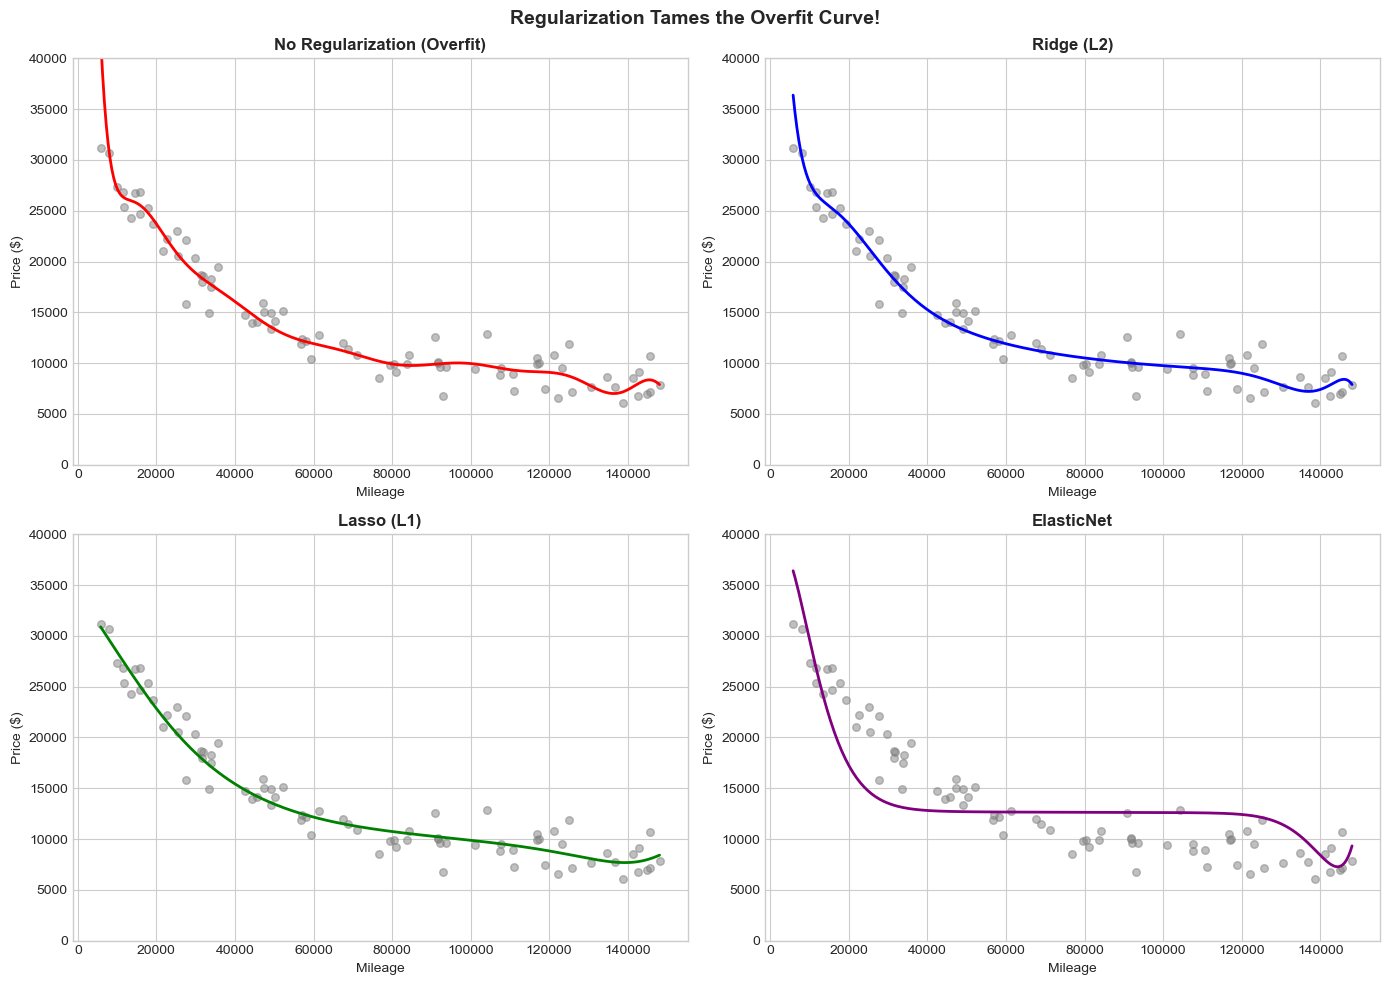

Notice how regularization smooths out the wiggly overfit curve!


In [37]:
# Visualize the regularization effect
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

X_plot_high = poly_high.transform(X_plot_scaled)

models = [
    (model_no_reg, 'No Regularization (Overfit)', 'red'),
    (ridge_model, 'Ridge (L2)', 'blue'),
    (lasso_model, 'Lasso (L1)', 'green'),
    (elastic_model, 'ElasticNet', 'purple')
]

for ax, (model, title, color) in zip(axes.flatten(), models):
    ax.scatter(df_cars['Mileage'], df_cars['Price'], color='gray', alpha=0.5, s=30)
    
    y_plot = model.predict(X_plot_high)
    
    ax.plot(X_plot, y_plot, color=color, linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Mileage')
    ax.set_ylabel('Price ($)')
    ax.set_ylim(0, 40000)

plt.suptitle('Regularization Tames the Overfit Curve!', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Notice how regularization smooths out the wiggly overfit curve!")

---
## 🎯 Your Turn: Apply Regularization to Housing Data

Apply Ridge and Lasso to the **housing data** polynomial features!

**Your Task:**
1. Create polynomial features (degree 3) from housing data
2. Train Ridge and Lasso models
3. Compare their train/test gaps

In [38]:
# 🎯 PRACTICE: Regularization on Housing Data
# Apply Ridge and Lasso to polynomial housing features

# Step 1: Scale the housing data first (important for regularization!)
scaler_housing = StandardScaler()
X_train_scaled = scaler_housing.fit_transform(X_train_m)
X_test_scaled = scaler_housing.transform(X_test_m)

# Step 2: Create polynomial features (degree 3) for housing data
poly_housing_3 = PolynomialFeatures(degree=3, include_bias=False)
X_train_housing_poly3 = poly_housing_3.fit_transform(X_train_scaled)
X_test_housing_poly3 = poly_housing_3.transform(X_test_scaled)

print(f"Polynomial features created: {X_train_housing_poly3.shape[1]} features")

# Step 3: Train Ridge model
# YOUR CODE HERE - Create and fit a Ridge model with alpha=1.0
ridge_housing = # YOUR CODE HERE
# YOUR CODE HERE - Fit the model


# Step 4: Train Lasso model  
# YOUR CODE HERE - Create and fit a Lasso model with alpha=1.0
lasso_housing = # YOUR CODE HERE
# YOUR CODE HERE - Fit the model


# Step 5: Calculate and compare scores
ridge_train = ridge_housing.score(X_train_housing_poly3, y_train_m)
ridge_test = ridge_housing.score(X_test_housing_poly3, y_test_m)

lasso_train = lasso_housing.score(X_train_housing_poly3, y_train_m)
lasso_test = lasso_housing.score(X_test_housing_poly3, y_test_m)

print("\n" + "="*50)
print("YOUR RESULTS: Regularization on Housing Data")
print("="*50)
print(f"Ridge - Train: {ridge_train:.4f}, Test: {ridge_test:.4f}, Gap: {ridge_train-ridge_test:.4f}")
print(f"Lasso - Train: {lasso_train:.4f}, Test: {lasso_test:.4f}, Gap: {lasso_train-lasso_test:.4f}")
print("="*50)

SyntaxError: invalid syntax (3120330766.py, line 18)

---
# Part 6: Hyperparameter Tuning
## Finding the Best Settings for Your Model

> **Analogy:** Hyperparameter tuning is like adjusting the settings on a coffee machine. The beans (data) are fixed, but you can dial in the grind size, water temperature, and brew time. GridSearchCV tries every combination of settings and tells you which makes the best coffee - I mean, model.

**Hyperparameters** are the "knobs" you set BEFORE training:
- Decision Tree: `max_depth`, `min_samples_split`
- KNN: `n_neighbors`
- Ridge/Lasso: `alpha`

In [39]:
# Let's tune a Decision Tree!

# Define the hyperparameter grid - all combinations we want to try
param_grid = {
    'max_depth': [2, 3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Parameter grid to search:")
print(f"  max_depth options: {param_grid['max_depth']}")
print(f"  min_samples_split options: {param_grid['min_samples_split']}")
print(f"  min_samples_leaf options: {param_grid['min_samples_leaf']}")
print(f"\nTotal combinations to try: {6 * 3 * 3} = 54")

Parameter grid to search:
  max_depth options: [2, 3, 4, 5, 6, 7]
  min_samples_split options: [2, 5, 10]
  min_samples_leaf options: [1, 2, 4]

Total combinations to try: 54 = 54


In [40]:
# Create the grid search
tree_for_tuning = DecisionTreeRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=tree_for_tuning,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1  # Use all CPU cores
)

# Fit (this tries all 54 combinations with 5-fold CV = 270 models!)
print("Running GridSearchCV...")
print("(Trying all 54 combinations with 5-fold cross-validation)")
grid_search.fit(X_train_m, y_train_m)
print("Done!")

Running GridSearchCV...
(Trying all 54 combinations with 5-fold cross-validation)
Done!


In [41]:
# Best parameters found
print("=" * 50)
print("BEST HYPERPARAMETERS FOUND:")
print("=" * 50)
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest Cross-Validation Score: {grid_search.best_score_:.4f}")
print("=" * 50)

BEST HYPERPARAMETERS FOUND:
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 5

Best Cross-Validation Score: 0.9044


In [42]:
# Compare: default tree vs tuned tree
default_tree = DecisionTreeRegressor(random_state=42)
default_tree.fit(X_train_m, y_train_m)
default_score = default_tree.score(X_test_m, y_test_m)

tuned_tree = grid_search.best_estimator_
tuned_score = tuned_tree.score(X_test_m, y_test_m)

print("=" * 50)
print("DEFAULT vs TUNED Decision Tree")
print("=" * 50)
print(f"Default Tree R²:  {default_score:.4f}")
print(f"Tuned Tree R²:    {tuned_score:.4f}")
print(f"Improvement:      {tuned_score - default_score:+.4f}")
print("=" * 50)

DEFAULT vs TUNED Decision Tree
Default Tree R²:  0.8550
Tuned Tree R²:    0.8540
Improvement:      -0.0010


---
## 🎯 Your Turn: Tune Ridge Regression

Now use GridSearchCV to find the best `alpha` value for Ridge regression!

**Your Task:**
1. Define a parameter grid with different alpha values
2. Run GridSearchCV on the polynomial car data
3. Compare the tuned Ridge model to the default

In [43]:
# 🎯 PRACTICE: Tune Ridge Regression with GridSearchCV
# We'll find the best alpha value for Ridge on our polynomial car data

# Step 1: Define the parameter grid
# YOUR CODE HERE - create a dict with 'alpha' as key and a list of values to try
# Try values like: [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge_param_grid = # YOUR CODE HERE

# Step 2: Create GridSearchCV for Ridge
ridge_for_tuning = Ridge()

# YOUR CODE HERE - Create the GridSearchCV object
# Use cv=5 and scoring='r2'
ridge_grid_search = GridSearchCV(
    estimator=ridge_for_tuning,
    param_grid=# YOUR CODE HERE,
    cv=# YOUR CODE HERE,
    scoring=# YOUR CODE HERE
)

# Step 3: Fit on the high-degree polynomial data
# YOUR CODE HERE - fit the grid search on X_train_high, y_train_car


# Step 4: Print results
print("="*50)
print("RIDGE TUNING RESULTS")
print("="*50)
print(f"Best alpha: {ridge_grid_search.best_params_['alpha']}")
print(f"Best CV Score: {ridge_grid_search.best_score_:.4f}")

# Compare to default Ridge (alpha=1.0)
tuned_ridge_score = ridge_grid_search.best_estimator_.score(X_test_high, y_test_car)
print(f"\nDefault Ridge (alpha=1.0) Test R²: {r2_ridge_test:.4f}")
print(f"Tuned Ridge Test R²: {tuned_ridge_score:.4f}")
print("="*50)

SyntaxError: invalid syntax (2821527806.py, line 7)

---
# Part 7: Model Comparison & Summary
## Putting It All Together

In [44]:
# Create a comprehensive comparison table!

results = {
    'Model': [
        'Simple Linear',
        'Multiple Linear',
        'Decision Tree (depth=3)',
        'Decision Tree (Tuned)'
    ],
    'R² Score': [
        r2_simple,
        r2_multi,
        r2_tree,
        tuned_score
    ],
    'RMSE ($)': [
        rmse_simple,
        rmse_multi,
        rmse_tree,
        np.sqrt(mean_squared_error(y_test_m, tuned_tree.predict(X_test_m)))
    ]
}

comparison_df = pd.DataFrame(results)
comparison_df['R² Score'] = comparison_df['R² Score'].round(4)
comparison_df['RMSE ($)'] = comparison_df['RMSE ($)'].round(2)

# Sort by R² score
comparison_df = comparison_df.sort_values('R² Score', ascending=False)

print("=" * 70)
print("FINAL MODEL COMPARISON - Housing Data")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

NameError: name 'r2_simple' is not defined

NameError: name 'comparison_df' is not defined

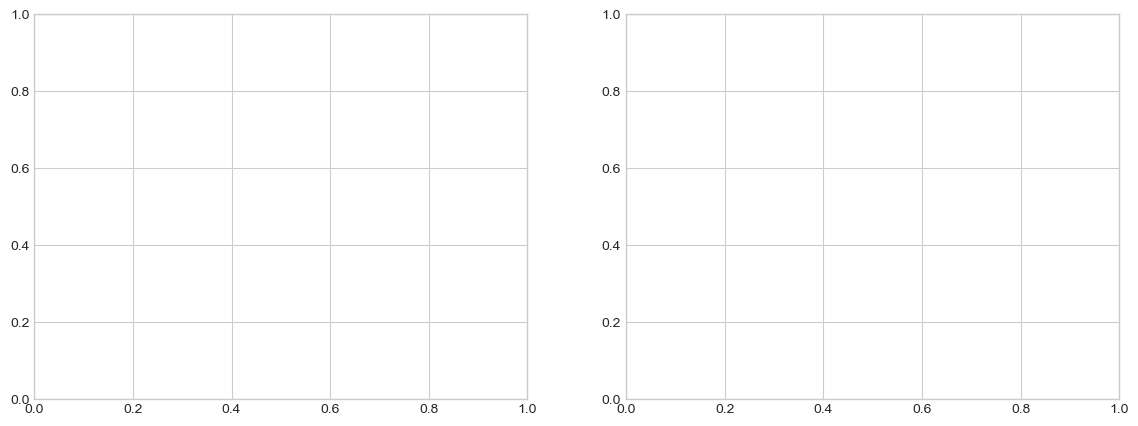

In [45]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

# R² Score comparison
axes[0].barh(comparison_df['Model'], comparison_df['R² Score'], color=colors)
axes[0].set_xlabel('R² Score', fontsize=12)
axes[0].set_title('Model Comparison: R² Score (Higher is Better)', fontsize=12)
axes[0].set_xlim(0, 1)

# RMSE comparison
axes[1].barh(comparison_df['Model'], comparison_df['RMSE ($)'], color=colors)
axes[1].set_xlabel('RMSE ($)', fontsize=12)
axes[1].set_title('Model Comparison: RMSE (Lower is Better)', fontsize=12)

plt.tight_layout()
plt.show()

---
## 🎯 Your Turn: Add Your Best Model to the Comparison

Add your best polynomial model from the car data to the comparison!

**Your Task:**
1. Get the R² and RMSE for your best polynomial model (car data)
2. Create a new row for the comparison DataFrame
3. Print the updated comparison

In [46]:
# 🎯 PRACTICE: Add Your Model to the Comparison
# Let's add the polynomial regression results from the car data

# Step 1: We already have r2_poly2 and rmse_poly2 from Part 2
# Let's create a new results dictionary including this model

# YOUR CODE HERE - Create a new row as a dictionary
new_model = {
    'Model': # YOUR CODE HERE - give it a descriptive name like 'Polynomial (Car Data)'
    'R² Score': # YOUR CODE HERE - use the r2_poly2 variable
    'RMSE ($)': # YOUR CODE HERE - use the rmse_poly2 variable
}

# Step 2: Add to comparison (hint: use pd.concat or comparison_df.append)
# YOUR CODE HERE
new_row_df = pd.DataFrame([new_model])
extended_comparison = # YOUR CODE HERE - concatenate comparison_df with new_row_df

# Step 3: Display the results
print("="*70)
print("EXTENDED MODEL COMPARISON")
print("="*70)
print(extended_comparison.to_string(index=False))
print("="*70)

SyntaxError: invalid syntax (3764855314.py, line 10)

---
## Key Takeaways

### 1. Start Simple, Add Complexity Only If Needed
Linear regression is interpretable and often works surprisingly well. Don't reach for complex models first!

### 2. Always Check for Overfitting
Compare train vs test performance. A big gap means your model is memorizing, not learning.

### 3. Regularization Is Your Friend
Ridge, Lasso, and ElasticNet help prevent overfitting. Lasso is especially useful for feature selection.

### 4. Different Models Have Different Strengths

| Model | Best For |
|-------|----------|
| Linear Regression | Simple, interpretable baselines |
| Polynomial | Curved relationships |
| Decision Tree | Non-linear, interpretable (can see the logic) |
| Ridge/Lasso | When you have many features, prevent overfitting |

### 5. Interpretability Matters
Especially in healthcare and other high-stakes domains, being able to explain WHY a model made a prediction is crucial.

### Coming Up Next!
- More regression models (KNN, SVR, Bayesian)
- Ensemble methods (Random Forest, XGBoost) - combining multiple models for even better predictions!

---
## Quick Reference: Scikit-Learn Code Patterns

```python
# Basic pattern for any model
from sklearn.model_class import ModelName

model = ModelName(hyperparameters)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
score = model.score(X_test, y_test)  # R² for regression

# Polynomial Features
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_scaled)

# Regularization
from sklearn.linear_model import Ridge, Lasso, ElasticNet
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=1.0)
elastic = ElasticNet(alpha=1.0, l1_ratio=0.5)

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(model, param_grid, cv=5)
grid.fit(X, y)
best_params = grid.best_params_
best_model = grid.best_estimator_
```

In [47]:
print("\n" + "="*60)
print("Congratulations! You've completed the Regression Algorithms")
print("walkthrough. You now have a solid toolkit of regression models!")
print("="*60)


Congratulations! You've completed the Regression Algorithms
walkthrough. You now have a solid toolkit of regression models!
